In [1]:
from destruction_utilities import *
import numpy as np
import zarr
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC
import shutil
from tensorflow.keras.utils import Sequence
import os


In [6]:
CITY = 'test'
TILE_SIZE = (128,128)
THRESHOLD = 0.5

auc = AUC(
    num_thresholds=200,
    curve='ROC',
    name="auc"
)

model_path = f'../models/{CITY}/cnn'
images = search_data(pattern(city=CITY, type='image'))
best_model = load_model(model_path, custom_objects={'f1_m':f1_m, 'precision_m': precision_m, 'recall_m': recall_m, 'auc': auc})

In [8]:
images = [images]

In [10]:
def tiled_profile(source:str, tile_size:tuple=(*TILE_SIZE, 1)) -> dict:
    '''Computes raster profile for tiles'''
    raster  = rasterio.open(source)
    profile = raster.profile
    assert profile['width']  % tile_size[0] == 0, 'Invalid dimensions'
    assert profile['height'] % tile_size[1] == 0, 'Invalid dimensions'
    affine  = profile['transform']
    affine  = rasterio.Affine(affine[0] * tile_size[0], affine[1], affine[2], affine[3], affine[4] * tile_size[1], affine[5])
    profile.update(width=profile['width'] // tile_size[0], height=profile['height'] // tile_size[0], count=tile_size[2], transform=affine)
    return profile

class CNNTestGenerator(Sequence):
    def __init__(self, images, batch_size=32):
        self.images = images
        self.batch_size = batch_size
        
    def __len__(self):
        return len(self.images)//self.batch_size
    
    def __getitem__(self, index):
        if(index == self.__len__()-1):
            X = self.images[index*self.batch_size:len(self.images)]
        else:
            X = self.images[index*self.batch_size:(index+1)*self.batch_size]            
        return X
    
    def augment(self, X):        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha
        
        return X
    
for image in images:
    profile = tiled_profile(image, tile_size=(*TILE_SIZE, 1))
    name = image.split("image_")[1]
    image = np.array(read_raster(image))
    h,w,b = image.shape
    image = image.reshape(1,h,w,b)
    image = tile_sequences(image, tile_size=TILE_SIZE)   
    image = image.reshape(image.shape[0], image.shape[2], image.shape[3], image.shape[4])
    if os.path.exists('temp.zarr'):
        shutil.rmtree("temp.zarr")
    zarr.save("temp.zarr", np.empty((0,image.shape[1], image.shape[2], image.shape[3])))
    temp = zarr.open("temp.zarr", mode = 'a')
    temp.append(image)
    
    test_images = CNNTestGenerator(temp)
    labels = best_model.predict_generator(test_images)
#     labels = np.greater(labels, THRESHOLD).astype('int')
    
    
    write_raster(labels.reshape((profile['height'], profile['width'])), profile, f"../data/{CITY}/predictions/prediction_{name}", dtype='float32')    
    print(name.split(".tif")[0])
    


/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_71050/1493404377.py:49: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  labels = best_model.predict_generator(test_images)
2022-07-15 06:50:57.593434: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-07-15 06:50:58.201102: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2016_09_18


In [ ]:
import gc
gc.collect(generation=2)

In [ ]:
image=images[3]

In [11]:
write_raster(labels.reshape((profile['height'], profile['width'])), profile, f"../data/{CITY}/predictions/prediction_{name}", dtype='float32')    


In [12]:
import zarr


In [45]:
train_t0 = read_zarr('aleppo', 'images_siamese_train_t0_balanced')
train_tt = read_zarr('aleppo', 'images_siamese_train_tt_balanced')
labels = read_zarr('aleppo', 'labels_siamese_train_balanced')


True


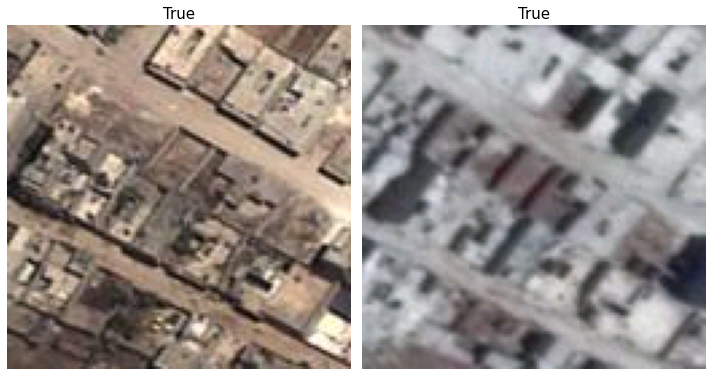

In [60]:
id = 200000

print(labels[id])

img1 = train_t0[id].reshape((128,128,3))
img2 = train_tt[id].reshape((128,128,3))
compare([img1, img2], titles = [str(labels[id])])

In [34]:
train_t0.shape

(203688, 128, 128, 3)

In [ ]:
h

In [ ]:
w